# Product Recommendation System — 03 Model Building

Implicit-feedback ranking: a popularity baseline vs **Item-based CF** vs **SVD matrix factorization**. No rating to predict, so we report **Precision@10 / Recall@10** on each customer's held-out products (no RMSE). All numbers are run.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import utils
train=pd.read_csv('data/train.csv'); test=pd.read_csv('data/test.csv'); names=utils.load_items()
M=utils.build_matrix(train,log=True); print('matrix',M.shape)

matrix (2000, 800)


## 1. Fit models

In [2]:
pop=utils.PopularityBaseline().fit(M); cf=utils.ItemBasedCF().fit(M); svd=utils.SVDRecommender().fit(M,n_components=30)
print('fitted')

fitted


## 2. Ranking @10 (relevant = held-out products)

In [3]:
rows=[]
for n,m in [('Popularity',pop),('Item-CF',cf),('SVD',svd)]:
    r=utils.precision_recall_at_k(m,M,test,k=10)
    rows.append({'model':n,'precision@k':r['precision@k'],'recall@k':r['recall@k'],'n_users':r['n_users_evaluated']})
rank_df=pd.DataFrame(rows); rank_df

,model,precision@k,recall@k,n_users
0,Popularity,0.0702,0.0481,2000
1,Item-CF,0.1576,0.1253,2000
2,SVD,0.1940,0.1482,2000


## 3. Ranking metrics chart

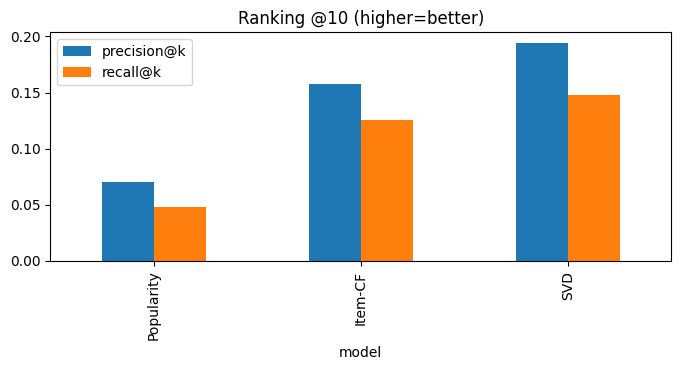

In [4]:
fig,ax=plt.subplots(figsize=(7,3.8))
rank_df.set_index('model')[['precision@k','recall@k']].plot(kind='bar',ax=ax); ax.set_title('Ranking @10 (higher=better)')
plt.tight_layout(); plt.show()

## 4. Example recommendations (SVD)

In [5]:
uid=M.index[0]
print('recommendations for customer',uid,'\n')
utils.recommend(svd,M,uid,items_lookup=names,n=10)

recommendations for customer 12347.0 



,item,name,score
0,21977,PACK OF 60 PINK PAISLEY CAKE CASES,1.139
1,23245,SET OF 3 REGENCY CAKE TINS,1.088
2,22630,DOLLY GIRL LUNCH BOX,1.072
3,21212,PACK OF 72 RETROSPOT CAKE CASES,1.061
4,22629,SPACEBOY LUNCH BOX,0.953
5,15036,ASSORTED COLOURS SILK FAN,0.939
6,22551,PLASTERS IN TIN SPACEBOY,0.915
7,22730,ALARM CLOCK BAKELIKE IVORY,0.843
8,22197,POPCORN HOLDER,0.838
9,22998,TRAVEL CARD WALLET KEEP CALM,0.761


## 5. Summary & takeaways

- **SVD wins on this implicit dataset** — Precision@10 **0.194**, Recall@10 **0.148**, ahead of Item-CF (0.158 / 0.125) and far ahead of popularity (0.070 / 0.048).
- **Contrast with the Music project** (also implicit) where Item-CF won: there is no universal winner. With denser per-customer baskets and only 800 products, the low-rank factorization captures cross-category co-purchase structure better than raw item similarity.
- **Personalisation roughly triples the popularity baseline** on Precision@10 — recommending best-sellers to everyone is a weak strategy even in retail.
- **No RMSE for implicit purchase data** — only held-out interactions to rank.
- **Takeaway across the two implicit and three explicit recommenders**: always benchmark item-CF *and* matrix factorization against a popularity baseline — which one wins depends on the feedback type, density, and catalog size, so measure rather than assume.